In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import os

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

In [ ]:
# Step 1: Folder path
folder_path = "/content/drive/MyDrive/dataset"   # your folder

In [ ]:
# Step 2: Read all CSV files
all_files = [f for f in os.listdir(folder_path) if f.endswith('.csv')]

dataframes = []

for file in all_files:
    path = os.path.join(folder_path, file)
    df = pd.read_csv(path)

    print(f"Loaded {file} → shape: {df.shape}")

    # Step 3: Standardize target column
    # Adjust based on your dataset
    if 'bug' in df.columns:
        target = 'bug'
    elif 'defects' in df.columns:
        target = 'defects'
    elif 'label' in df.columns:
        target = 'label'
    else:
        print(f"Skipping {file} (no target column)")
        continue

    df[target] = df[target].apply(lambda x: 1 if x > 0 else 0)

    # Rename target to common name
    df = df.rename(columns={target: 'target'})

    dataframes.append(df)

Loaded data_ivy-2.0 (1).csv → shape: (352, 21)
Loaded lucene-2.0.csv → shape: (195, 21)
Loaded camel-1.0.csv → shape: (339, 21)
Loaded data_arc (1).csv → shape: (225, 21)
Loaded jedit-3.2.csv → shape: (272, 21)
Loaded ant-1.7 (1).csv → shape: (745, 21)
Loaded jedit-4.2.csv → shape: (367, 21)
Loaded xalan-2.4.csv → shape: (723, 21)
Loaded synapse-1.2.csv → shape: (256, 21)
Loaded synapse-1.0.csv → shape: (157, 22)
Loaded data_prop-6 (1).csv → shape: (644, 21)
Loaded camel-1.6 (1).csv → shape: (965, 22)
Loaded xerces-1.2.csv → shape: (440, 22)
Loaded xerces-1.3.csv → shape: (453, 21)
Loaded log4j-1.1.csv → shape: (109, 21)
Loaded velocity-1.6.csv → shape: (229, 21)
Loaded poi-2.0.csv → shape: (314, 21)
Loaded data_redaktor (1).csv → shape: (175, 21)


# New Section

In [ ]:
# Step 4: Find all unique columns across all datasets
all_unique_cols = set()
for df in dataframes:
    all_unique_cols.update(df.columns)

# Ensure 'target' is not treated as a feature column for this step
if 'target' in all_unique_cols:
    all_unique_cols.remove('target')

# Add 'target' back if it was removed, to ensure it's in the combined data
# but we will handle it separately later for X and y split.
# For now, we want all potential features plus target.
all_unique_cols = list(all_unique_cols)

print("All unique feature columns (excluding target for now):")
print(all_unique_cols)


All unique feature columns (excluding target for now):
['lcom3', 'lcom', 'npm', 'dam', 'moa', 'rfc', 'ca', 'mfa', 'ic', 'cbo', 'wmc', 'dit', 'ce', 'max_cc', 'amc', 'cbm', 'Unnamed: 21', 'sno', 'cam', 'loc', 'avg_cc', 'noc']


In [ ]:
# Step 5 & 6: Combine all datasets, aligning columns and filling missing with NaN
# Use 'outer' join to include all columns from all dataframes
final_df = pd.concat(dataframes, ignore_index=True, join='outer')

# Now, re-ensure 'target' is correctly handled and any non-numeric columns are dropped
# (which could have been introduced by new columns with NaNs if not careful with dtypes).

# Drop columns that are not numerical or are entirely NaN after concatenation (if any)
# This is a robust way to clean up after outer join if datasets had very different structures
final_df = final_df.select_dtypes(include=np.number)

# Ensure 'target' is still present; if not, there's a serious data issue upstream
if 'target' not in final_df.columns:
    raise ValueError("'target' column not found in the combined dataset. Check data loading and target standardization.")

print("Final dataset shape:", final_df.shape)
print("Columns in final dataset:", final_df.columns.tolist())


Final dataset shape: (6960, 22)
Columns in final dataset: ['wmc', 'dit', 'noc', 'cbo', 'rfc', 'lcom', 'ca', 'ce', 'npm', 'lcom3', 'loc', 'dam', 'moa', 'mfa', 'cam', 'ic', 'cbm', 'amc', 'max_cc', 'avg_cc', 'target', 'sno']


In [ ]:
# Step 7: Handle missing values
final_df = final_df.fillna(final_df.mean())

# Step 8: Split features and target
X = final_df.drop(columns=['target'])
y = final_df['target']


In [ ]:
# Step 9: Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
# Step 10: Train Random Forest
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',   # important for defect data
    random_state=42
)

rf.fit(X_train, y_train)

# Step 11: Predictions
y_pred = rf.predict(X_test)

# Step 12: Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8175287356321839

Classification Report:
               precision    recall  f1-score   support

           0       0.49      0.22      0.30       251
           1       0.85      0.95      0.90      1141

    accuracy                           0.82      1392
   macro avg       0.67      0.58      0.60      1392
weighted avg       0.78      0.82      0.79      1392




--- Confusion Matrix ---


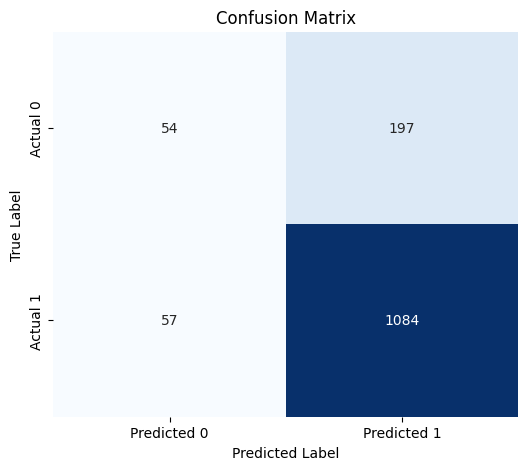


--- ROC Curve ---


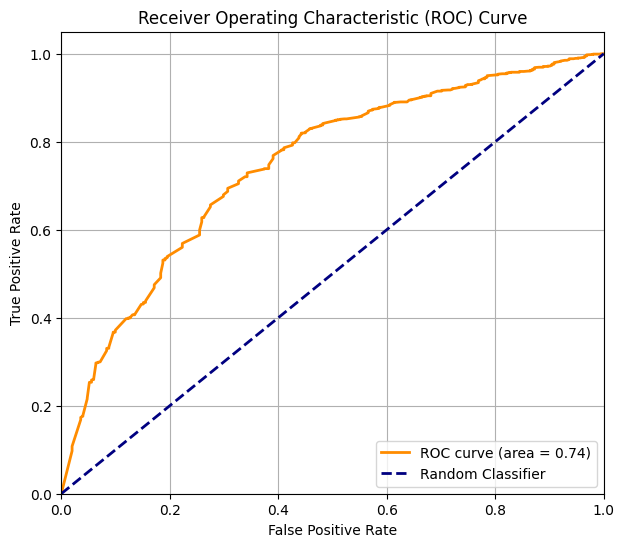


--- Precision-Recall Curve ---


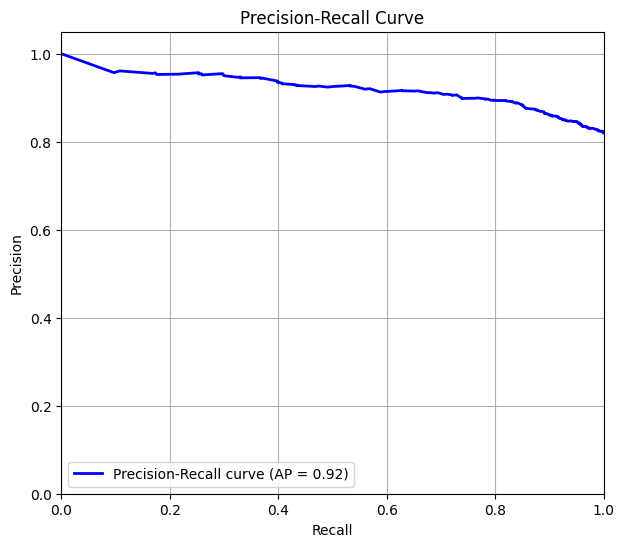

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_curve, average_precision_score

# --- Confusion Matrix ---
print("\n--- Confusion Matrix ---")
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# --- ROC Curve ---
print("\n--- ROC Curve ---")
# Get probability estimates for the positive class
y_pred_proba = rf.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# --- Precision-Recall Curve ---
print("\n--- Precision-Recall Curve ---")
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
# Average precision (AP) summarizes the precision-recall curve
# This is a common metric for imbalanced datasets
AP = average_precision_score(y_test, y_pred_proba)

plt.figure(figsize=(7, 6))
plt.plot(recall, precision, color='blue', lw=2, label=f'Precision-Recall curve (AP = {AP:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')
plt.grid(True)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.show()


In [ ]:
from sklearn.metrics import cohen_kappa_score, f1_score, balanced_accuracy_score, precision_score, recall_score, matthews_corrcoef, confusion_matrix

# Recalculate Confusion Matrix if not already available in this scope
# (It was calculated in the previous cell and stored in 'cm')
# If 'cm' is not available here, you would need to uncomment the line below:
# cm = confusion_matrix(y_test, y_pred)

# Extract TN, FP, FN, TP from the confusion matrix
# This assumes binary classification where 0 is negative and 1 is positive
tn, fp, fn, tp = cm.ravel()

# Calculate Specificity (True Negative Rate)
specificity = tn / (tn + fp)

print("--- Additional Metrics on Test Dataset ---")

# Cohen's Kappa
kappa = cohen_kappa_score(y_test, y_pred)
print(f"Cohen's Kappa: {kappa:.4f}")

# F1-score (for the positive class, typically '1')
f1 = f1_score(y_test, y_pred)
print(f"F1-Score (Positive Class): {f1:.4f}")

# Balanced Accuracy
balanced_acc = balanced_accuracy_score(y_test, y_pred)
print(f"Balanced Accuracy: {balanced_acc:.4f}")

# Precision (for the positive class)
precision = precision_score(y_test, y_pred)
print(f"Precision (Positive Class): {precision:.4f}")

# Recall (for the positive class) - This is the same as TPR
recall = recall_score(y_test, y_pred)
print(f"Recall (Positive Class): {recall:.4f}")

# Specificity (True Negative Rate)
print(f"Specificity (True Negative Rate): {specificity:.4f}")

# Matthew's Correlation Coeffici ent (MCC)
mcc = matthews_corrcoef(y_test, y_pred)
print(f"Matthew's Correlation Coefficient (MCC): {mcc:.4f}")


--- Additional Metrics on Test Dataset ---
Cohen's Kappa: 0.2111
F1-Score (Positive Class): 0.8951
Balanced Accuracy: 0.5826
Precision (Positive Class): 0.8462
Recall (Positive Class): 0.9500
Specificity (True Negative Rate): 0.2151
Matthew's Correlation Coefficient (MCC): 0.2344
